In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv('opcode_results/PICKITEM.csv')

In [3]:
def plot_target_vs_each_feature(X: pd.DataFrame, y: pd.Series):
    y_vals = y.values.reshape(-1)
    for col in X.columns:
        x_vals = X[col].values
        plt.figure(figsize=(8, 5))
        plt.scatter(x_vals, y_vals)
        plt.xlabel(col)
        plt.ylabel("ns")
        plt.title(f"ns vs {col}")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

In [4]:
def analytic_linear_regression(X: pd.DataFrame, y: pd.Series) -> np.ndarray:
    X_mat = X.values
    y_vec = y.values

    n = X_mat.shape[0]
    X_design = np.hstack([X_mat, np.ones((n, 1))])

    beta, _, _, _ = np.linalg.lstsq(X_design, y_vec, rcond=None)

    return beta

In [5]:
def myfunc(df_type: pd.DataFrame, lstVariableNames):
    X = df_type[lstVariableNames]
    y = df_type["ns"]

    plot_target_vs_each_feature(X, y)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    beta = analytic_linear_regression(X_train, y_train)
    
    X_test_mat = X_test.values
    X_test_design = np.hstack([X_test_mat, np.ones((X_test_mat.shape[0], 1))])
    y_pred = X_test_design @ beta
    r2 = r2_score(y_test, y_pred)
    
    return beta, r2

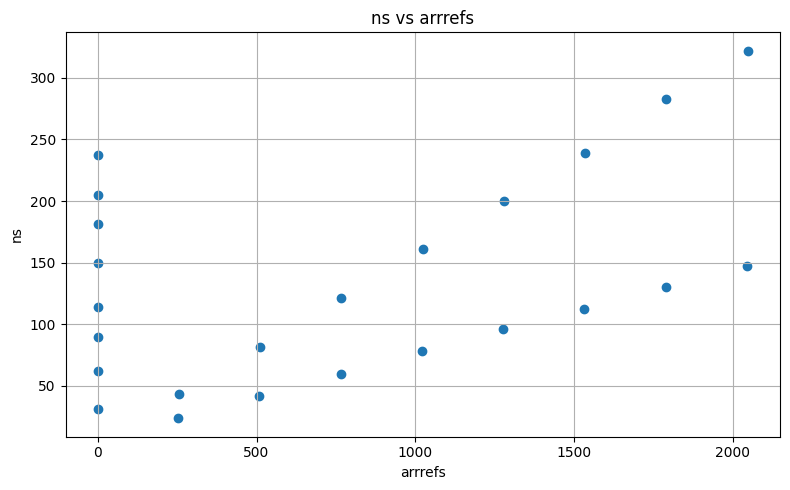

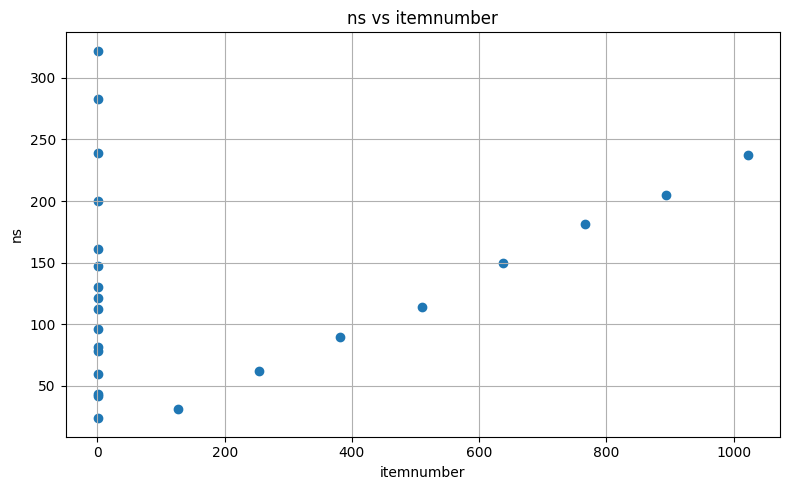

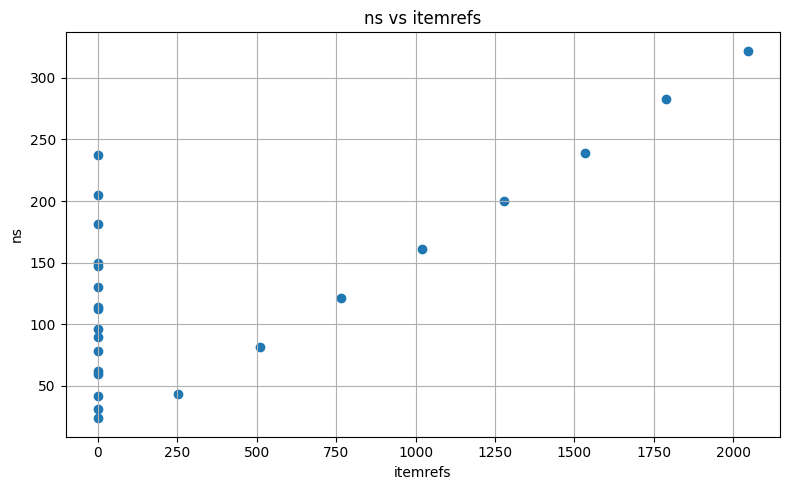

[  718  2294   840 20461]
0.9966354470791252


In [9]:
beta, r2 = myfunc(df[df["itemtype"] == "Any"], ["arrrefs", "itemnumber", "itemrefs"])
print(np.int64(np.round(beta*10000)))
print(r2)

In [7]:
def myfunc_w(X, y, power=1.0):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    X_train_mat = X_train.to_numpy(dtype=float)
    X_test_mat  = X_test.to_numpy(dtype=float)
    ys = y_train.to_numpy(dtype=float)

    max_j = np.max(X_train_mat, axis=0)

    normalized = X_train_mat / max_j
    sum_norm = np.sum(normalized, axis=1)

    weights = 1.0 / (sum_norm ** power)

    A = np.hstack([X_train_mat, np.ones((X_train_mat.shape[0], 1))])

    W = weights[:, None]
    A_w = W * A
    y_w = W.ravel() * ys

    beta, *_ = np.linalg.lstsq(A_w, y_w, rcond=None)

    A_test = np.hstack([X_test_mat, np.ones((X_test_mat.shape[0], 1))])
    y_pred = A_test @ beta

    r2 = float(r2_score(y_test.to_numpy(dtype=float), y_pred))

    return beta, r2

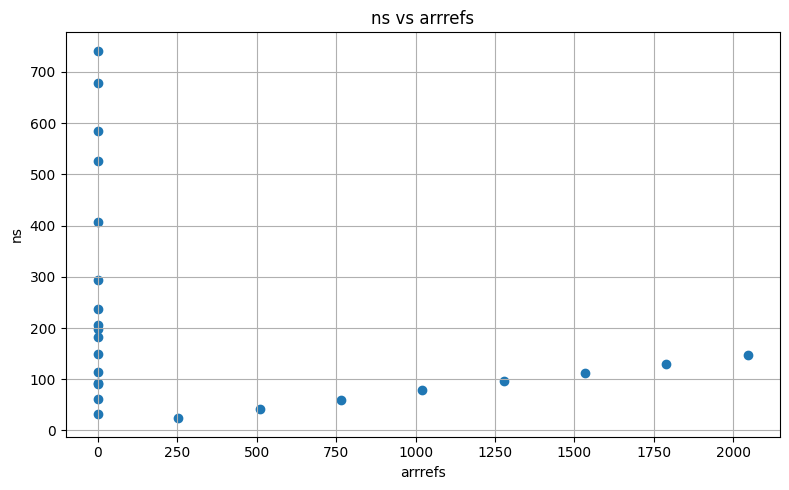

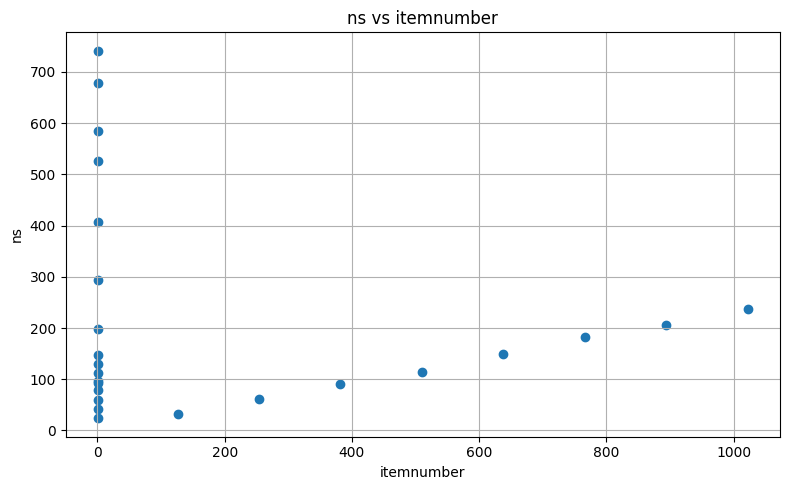

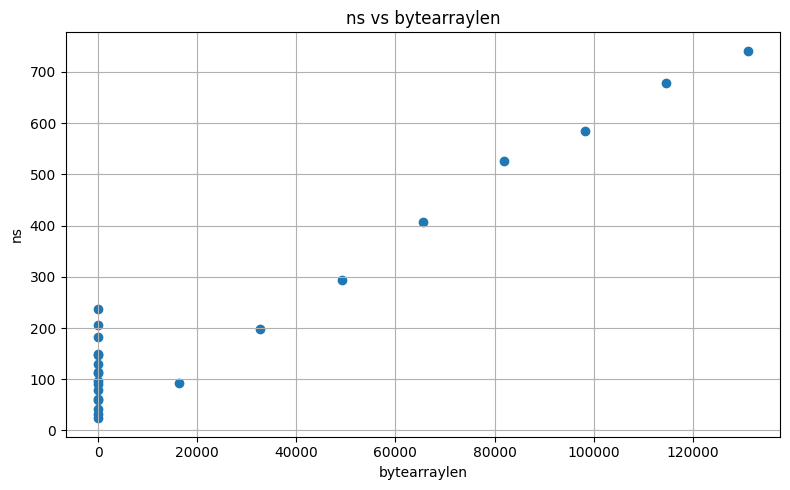

[  765  2315    60 16216]
0.9795548887711293


In [13]:
X = df[df["itemrefs"] == 1][["arrrefs", "itemnumber", "bytearraylen"]]
y = df[df["itemrefs"] == 1]["ns"]
plot_target_vs_each_feature(X, y)
beta, r2 = myfunc_w(X, y, 2.0)
print(np.int64(np.round(beta*10000)))
print(r2)